<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل پانزدهم: یادگیری تجمیعی: ترکیب مدل‌ها برای بهبود مدل‌ها</h2>
</div>

<div dir="rtl" align="right">

# مثال تکمیلی رگرسیون زمانی با XGBoost

فایل co2.csv مقادیر ماهانهٔ Value را همراه YYYYMM دارد. با سال و ماه، مقدار دورهٔ پایانی فایل را برآورد می‌کنیم. تاریخ هر پیش‌بینی همان تاریخ واقعیِ ردیف آزمون است.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## 1. مرتب‌سازی زمان و جداسازی انتهای سری

۸۰ درصد نخستِ ماه‌ها برای آموزش و بقیه برای آزمون است. این تقسیم با ادعای ارزیابی روی زمان بعد سازگار است.

</div>

In [2]:
# مرتب‌سازی زمان و جداسازی انتهای سری
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = pd.read_csv(DATA / "co2.csv")
data["Date"] = pd.to_datetime(data["YYYYMM"].astype(str), format="%Y%m")
data["Value"] = pd.to_numeric(data["Value"], errors="raise")
data = data.sort_values("Date").reset_index(drop=True)
assert data["Date"].is_unique and data["Value"].notna().all()
data["Month"] = data["Date"].dt.month
data["Year"] = data["Date"].dt.year
cut = int(len(data) * 0.8)
train, test = data.iloc[:cut], data.iloc[cut:]
X_train, y_train = train[["Month", "Year"]], train["Value"]
X_test, y_test = test[["Month", "Year"]], test["Value"]
print("Train ends:", train["Date"].max().date())
print("Test begins:", test["Date"].min().date())

Train ends: 2007-10-01
Test begins: 2007-11-01


<div dir="rtl" align="right">

## 2. برازش و محاسبهٔ خطا

R² مستقیماً محاسبه می‌شود؛ جذرِ آن R² نیست. پارامترها برای نمایش روش از پیش مشخص شده‌اند.

</div>

MAE: 29.591430416434154
RMSE: 35.15528916672758
R2: -1.1432477994676176


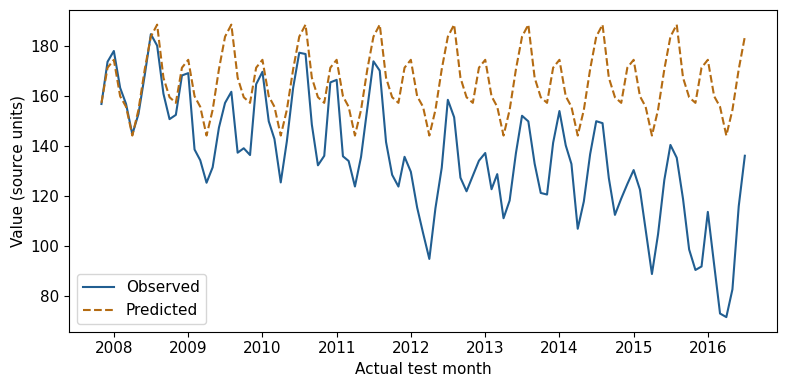

In [3]:
# برازش و محاسبهٔ خطا
model = XGBRegressor(n_estimators=1000, learning_rate=0.08,
                      subsample=0.75, colsample_bytree=1,
                      max_depth=7, gamma=0, random_state=42, n_jobs=2)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2:", r2_score(y_test, prediction))
plt.plot(test["Date"], y_test, color="#215e91", label="Observed")
plt.plot(test["Date"], prediction, "--", color="#b46b12", label="Predicted")
plt.xlabel("Actual test month")
plt.ylabel("Value (source units)")
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی
در این اجرا، RMSE حدود ۳۵٫۰۸ و R² حدود منفی ۱٫۱۳۴ است. نمودار نشان می‌دهد مدل کاهش مقادیر در سال‌های پایانی را خوب دنبال نمی‌کند؛ این نتیجه نمونه‌ای از محدودیت تعمیم زمانی است.

این نمودار فقط ماه‌های موجودِ آزمون را نشان می‌دهد. نسبت دادن پیش‌بینی‌های آزمون تصادفی به تاریخ‌های ساختگی، پیش‌بینی آینده محسوب نمی‌شود. مدل‌های درختی با ورودی سال و ماه نیز برای برون‌یابی روند به سال‌های دور محدودیت دارند.

</div>

<div dir="rtl" align="right">

## مأخذ مثال
مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>